# 3. 线性神经网络（下）

> softmax 分类相关

## 补充知识：2.2 数据预处理

> 核心操作：**读取、切片、补全、转换**。
>
> 在深度学习的工作流中，Pandas 扮演的是 **“洗菜工”** 的角色：它把原始的 CSV/Excel 变成干净的表格，然后交给 NumPy 变成数组，最后交给 PyTorch 变成张量。
>
> 以下是针对 2.2 节涉及到的 **Pandas 核心概念与类型**的细致拆解：

---

### 1. Pandas 的两大核心数据类型

#### `pd.DataFrame` (数据帧/电子表格)
*   **含义**：它就是 **Excel 里的一个工作表（Sheet）**。
*   **结构**：有行索引（Index）和列名（Columns）。
*   **在 PyTorch 中的地位**：它是原始数据进入程序的第一站。

#### `pd.Series` (系列/单列数据)
*   **含义**：DataFrame 中的 **某一列**。
*   **结构**：你可以把它看作是一个带标签的一维数组。
*   **关系**：一个 DataFrame 是由多个 Series 组成的。

---

### 2. 深度拆解：预处理中的 Pandas 操作

我们把之前的代码中涉及到的 Pandas “黑话”翻译成工程师能懂的逻辑：

#### (1) `data.iloc` (Integer Location - 整数索引)
*   **用法**：`data.iloc[行范围, 列范围]`
*   **逻辑**：完全像 PyTorch 的 Tensor 切片一样。
*   **例子**：`data.iloc[:, 0:2]` 表示“取所有行，以及第 0 到第 1 列（不含第 2 列）”。

#### (2) `data.fillna()` (Fill Not Available - 填充缺失值)
*   **含义**：找到表格里所有的 `NaN`（空值），并用你指定的数字替换。
*   **例子**：`inputs.fillna(inputs.mean())` 就是用这一列的平均值去填补空格。

#### (3) `pd.get_dummies()` (独热编码)
*   **这是深度学习中最重要的预处理步骤。**
*   **逻辑**：将“类别字符串”转为“数字 0/1”。
*   **例子**：
    *   原始列 `Alley` 有：`Pave`, `nan`。
    *   处理后变成两列：`Alley_Pave` (是 Pave 吗？) 和 `Alley_nan` (是空的吗？)。
    *   这样就把文字变成了神经网络能计算的 **0 和 1**。

### 3. 细致梳理：2.2 节的数学与工程重点

#### (1) 处理缺失值 (Missing Data)
在真实世界中，数据几乎永远是不完整的。
- **插值（Imputation）**：用均值、中位数填充。适合数值型。
- **删除（Deletion）**：如果某一行缺得太厉害，直接删掉。

#### (2) 类别特征的转译：One-hot Encoding (独热编码)
这是 2.2 节最关键的直觉。**计算机不认识“巷道(Alley)”或“猫/狗”这些字符串，它只认识数字。**
- 原始列 `Alley` 有两个值：`Pave` 和 `NaN`。
- `pd.get_dummies` 会把这一列拆成两列：
    - `Alley_Pave`: 如果是 Pave 则是 1，否则是 0。
    - `Alley_nan`: 如果缺失则是 1，否则是 0。
- **结论**：预处理后的特征矩阵 `X` 往往比原始表格更“宽”。

#### (3) 数据类型的转换
- **Pandas/NumPy**：默认精度很高（`float64`）。
- **PyTorch**：为了 GPU 计算效率，默认精度较低（`float32`）。
- **避坑点**：如果不执行 `.to(torch.float32)`，在后续做矩阵乘法时，PyTorch 会报错 `RuntimeError: expected scalar type float but found double`。


In [1]:
# 创建 CSV 数据
import os
import torch
import pandas as pd
from torch import Tensor

# 创建一个临时 CSV 文件作为实验数据
def create_raw_data_file(file_path: str) -> None:
    """创建一个模拟的原始数据 CSV 文件。"""
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, "w") as f:
        f.write("NumRooms,Alley,Price\n") # 列名
        f.write("NA,Pave,127500\n") # 第一行，NumRooms 缺失
        f.write("2,NA,106000\n") # 第二行，Alley 缺失
        f.write("4,NA,178100\n") # 第三行，Alley 缺失
        f.write("NA,NA,NA") # 第四行，全都缺失

data_file: str = os.path.join("temp", "data", "house_tiny.csv")
create_raw_data_file(data_file)

1.  **特征缺失** $\rightarrow$ **填充（Imputation）**：保留有用信息，减少噪声。
2.  **标签缺失** $\rightarrow$ **删除（Deletion）**：保证答案的纯净度，防止误导模型。


In [2]:
# 读取与处理 CSV 数据
def preprocess_csv_data(file_path: str) -> tuple[Tensor, Tensor]:
    """读取 CSV 文件并进行预处理，包括删除标签缺失行。
    
    Args:
        file_path: CSV 文件路径。

    Returns:
        包含 (特征张量, 标签张量) 的元组。
    """
    # 1. 使用 pandas 加载数据，返回类型是 pd.DataFrame (一张大表)
    df: pd.DataFrame = pd.read_csv(file_path)

    # 2. 处理标签列的缺失值
    # 逻辑：如果连正确答案（标签）都没有，这行数据对训练就是干扰，直接删掉。
    # subset = [df.columns[-1]] 表示检查最后一列
    df = df.dropna(subset=[df.columns[-1]])

    # 3. 提取特征和标签
    # inputs 是前两列 (pd.DataFrame)
    # outputs 是最后一列 (pd.Series)
    inputs: pd.DataFrame = df.iloc[:, 0:2]
    outputs: pd.Series = df.iloc[:, -1]

    # 4. 补全数值型缺失值
    # mean() 会对每一列求平均值，返回一个包含各列均值的 pd.Series
    mean_values: pd.Series = inputs.mean(numeric_only=True) # numeric_only=True 确保只计算数值列
    inputs = inputs.fillna(mean_values)

    # 5. 处理离散值（类别特征）
    # Alley 列有 "Pave" 和 "NA"。我们使用 One-hot 编码（独热编码）
    # dummy_na=True 会把 NaN 也当作一个合法的类别
    # 处理后的 inputs 依然是 pd.DataFrame，但列数可能增加了
    inputs = pd.get_dummies(inputs, dummy_na=True, dtype=float)

    # 6. 转换为张量
    # 步骤：DataFrame -> NumPy Array -> PyTorch Tensor
    # .values 或 .to_numpy() 会丢弃列名和索引，只保留纯数字矩阵
    # 注意：Pandas 默认使用 float64 (double)，但深度学习常用 float32
    x: Tensor = torch.tensor(inputs.to_numpy(), dtype=torch.float32)
    y: Tensor = torch.tensor(outputs.to_numpy(), dtype=torch.float32)

    return x, y

# 执行预处理
features_X, labels_y = preprocess_csv_data(data_file)
print(f"预处理后的特征:\n{features_X}")
print(f"预处理后的标签: {labels_y}")

预处理后的特征:
tensor([[3., 1., 0.],
        [2., 0., 1.],
        [4., 0., 1.]])
预处理后的标签: tensor([127500., 106000., 178100.])


## 3.5 图像分类数据集

In [3]:
# 下载数据集
import os
import torch 
import torchvision
from torchvision import transforms
from torch.utils import data
from typing import Optional, Callable
from pathlib import Path

# 定义全局数据根目录
DATA_ROOT: Path = Path("temp/data")

def download_fashion_mnist(root: Path = DATA_ROOT) -> None:
    """确保数据集已下载到本地。
    
    此函数是幂等的 (多次调用不产生副作用)。
    """
    # 仅下载，不进行任何变换
    # root: 数据存放路径
    # train: True 表示训练集，False 表示测试集
    torchvision.datasets.FashionMNIST(root=str(root), train=True, download=True)
    torchvision.datasets.FashionMNIST(root=str(root), train=False, download=True)
    print(f"Dataset check complete at: {root.absolute()}")

**`Callable` 的语法设计是为了区分“输入参数列表”和“单个返回值”。**

#### 语法标准格式

在 Python 的 `typing` 模块中，`Callable` 的完整定义方式是：

$$Callable[[参数1类型, 参数2类型, \dots], 返回值类型]$$

*   **第一个部分（输入参数）**：必须是一个**列表 `[]`**。因为一个函数可以接收 **0 个、1 个或多个**参数。为了囊括所有情况，Python 规定必须用列表把参数类型包起来。
*   **第二个部分（返回值）**：直接写**类型名**。因为在 Python 的逻辑中，一个函数永远只返回 **1 个**对象（即使返回多个值，本质上也是返回 1 个 `tuple`）。


In [4]:
# 预处理数据
# 原始图片 (-> 缩放 (Resize)) -> 转为张量 (ToTensor) -> 神经网络。
def get_fashion_mnist_dataset(
        root: Path = DATA_ROOT,
        resize: Optional[int] = None
) -> tuple[data.Dataset, data.Dataset]:
    """获取预处理后的数据集对象。
    
    Args:
        root: 数据存放路径。
        resize: 是否调整图像尺寸。
        
    Returns:
        (train_dataset, test_dataset)
    """
    # 1. 定义预处理流程 (Transforms)
    # transforms.ToTensor() 做两件事：
    #   a. 改变形状：从 (H, W, C) 变为 (C, H, W) -> 28x28x1 变为 1x28x28
    #   b. 归一化：将像素值从 [0, 255] 映射到 [0, 1] 的 float32
    trans: list[Callable] = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))

    # 组合多个预处理步骤
    trans_compose = transforms.Compose(trans)

    # 2. 加载数据并进行变换 (预处理)
    # 如果 download_fashion_mnist 没跑成功，这里会直接报错（因为 download = False）
    train_ds = torchvision.datasets.FashionMNIST(root=str(root), train=True, transform=trans_compose, download=False) 
    test_ds = torchvision.datasets.FashionMNIST(root=str(root), train=False, transform=trans_compose, download=False) 

    return train_ds, test_ds

In [5]:
# 生成迭代器
def load_fashion_mnist(
        batch_size: int,
        resize: Optional[int] = None,
        num_workers: int = 4
) -> tuple[data.dataloader, data.dataloader]:
    """整合下载、预处理与加载逻辑，返回最终的 DataLoader。

    这是供模型训练脚本调用的主入口函数。
    支持可选的图像尺寸调整，并默认使用多进程加速数据读取。
    
    Args: 
        batch_size: 每个训练批次的样本数量。
        resize: 可选参数。如果提供，图像将通过插值算法缩放为 (resize, resize) 形状。
        num_workers: 用于数据加载的子进程数量。在 Linux 环境下增加此值可加速读取。

    Returns:
        一个包含两个元素的元组。
        - train_iter (data.DataLoader): 训练数据集的迭代器，已开启随机打乱。
        - test_iter (data.DataLoader): 测试数据集的迭代器，不开启随机打乱。
    """
    # 1. 确保原始数据在硬盘上
    download_fashion_mnist()

    # 2. 获取经过预处理的数据集对象
    train_ds, test_ds = get_fashion_mnist_dataset(resize=resize)

    # 3. 创建高效的数据迭代器
    # shuffle=True: 在每个 epoch 开始时打乱数据，防止模型学到样本的先后顺序（偏见）
    # pin_memory=True: (可选) 如果使用 GPU，开启此项可以加快张量从内存复制到显存的速度
    train_iter = data.DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    test_iter = data.DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    return train_iter, test_iter

# 1. 尝试使用较大的 Batch Size 和 4 个进程
batch_size: int = 256
train_iter, test_iter = load_fashion_mnist(batch_size=batch_size)

# # 2. 计时读取第一个批次的速度
# import time
# start = time.time()
# X, y = next(iter(train_iter))
# print(f"读取一个 Batch ({batch_size} 张图) 耗时: {time.time() - start:.4f} 秒")
# print(f"Batch X 形状: {X.shape}") # [{batch_size}, 1, 28, 28]
# print(f"标签 y 形状: {y.shape}") # [batch_size]

Dataset check complete at: /home/august/deepseek/pytorch_study/temp/data


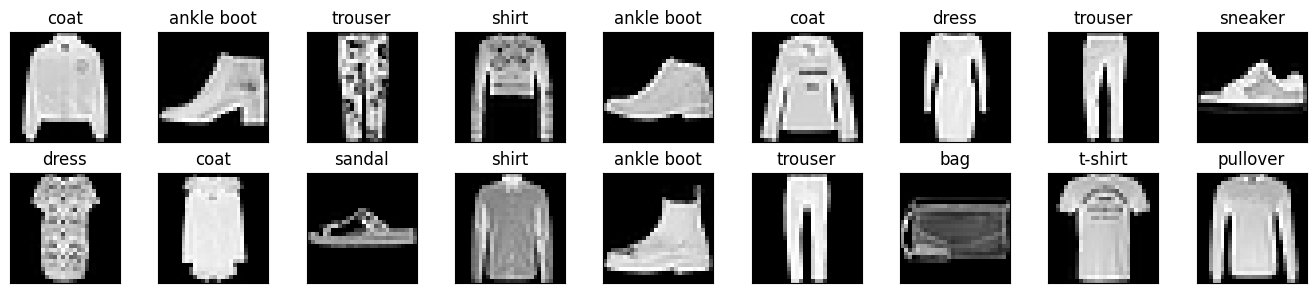

In [6]:
# 可视化
import matplotlib.pyplot as plt

def get_fashion_mnist_labels(labels: Tensor) -> list[str]:
    """返回 Fashion-MNIST 数据集的文本标签。"""
    # 1. 定义一个列表，索引 0-9 严格对应官方定义的类别名称
    text_labels: list[str] = [
        't-shirt', 'trouser', 'pullover', 'dress', 'coat',
        'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
    ]

    # 2. 列表推导式：遍历输入的 labels 张量
    # int(i) 将 Tensor 里的数字转为 Python 整数
    # text_labels[...] 根据这个整数从列表中取词
    return [text_labels[int(i)] for i in labels]

def show_images(
        imgs: Tensor,
        num_rows: int,
        num_cols: int,
        titles: Optional[list[str]] = None,
        scale: float = 1.5
) -> None:
    """绘制图像列表。"""
    # 1. 准备画布
    figsize = (num_cols * scale, num_rows * scale)
    # plt.subplots 会创建一个大图 (Figure) 和一堆小图区域 (Axes)
    # axes 是一个二维数组，比如 2 行 9 列
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    # 2. 展平坐标轴
    # axes 原本是 [[ax1, ax2...], [ax10, ax11...]]
    # flatten() 把它变成一维列表 [ax1, ax2, ..., ax18]
    # 这样我们就可以用一个循环直接遍历所有的位置
    axes = axes.flatten()

    # 3. 循环画图
    # zip(axes, imgs) 把“格子”和“图片”一一对应地打包
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        # 绘制前，需将 Tensor 转换为 NumPy
        # 【核心点】img.squeeze().numpy()
        # img 的形状原本是 (1, 28, 28) -> (通道, 高, 宽)
        # squeeze() 会去掉大小为 1 的维度，变成 (28, 28)
        # numpy() 将 PyTorch 张量转为 NumPy 数组，因为 matplotlib 只认识 NumPy
        ax.imshow(img.squeeze().numpy(), cmap='gray')

        # 隐藏坐标轴上的刻度（0, 5, 10...这些数字），让图片看起来更整洁
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)

        # 如果传了标题列表，就给每个小图加上标题
        if titles:
            ax.set_title(titles[i])

    # 自动调整子图之间的间距，防止标题和图片重叠在一起
    plt.tight_layout()
    plt.show()

# 抽样显示前 18 张图
X, y = next(iter(train_iter))
show_images(X[:18], 2, 9, titles=get_fashion_mnist_labels(y[:18]))

## 3.6 Softmax 回归的从零实现

> 处理分类问题

In [7]:
# 初始化模型参数
import torch
from torch import Tensor

# 输入维度：28 * 28 像素
num_inputs: int = 784
# 输出维度：10 个类别
num_outputs: int = 10

# 初始化权重 w 和偏置 b
# w 的形状是 (输入维度, 输出维度)
w: Tensor = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b: Tensor = torch.zeros(num_outputs, requires_grad=True)

In [8]:
# 定义 Softmax 操作
def softmax(X: Tensor) -> Tensor:
    """计算张量 X 的 Softmax。
    
    Args:
        X: 形状为 (batch_size, num_outputs) 的原始输出张量。

    Returns:
        经过指数化和归一化后的概率分布张量。
    """
    # 1. 对每个元素取指数。
    X_exp: Tensor = torch.exp(X)
    # 2. 对每一行求和 (保持维度以便广播)
    partition: Tensor = X_exp.sum(1, keepdim=True)
    # 3. 归一化：每个元素除以该行的总和
    return X_exp / partition

# 定义数值稳定的 Softmax 操作
def softmax_stable(X: Tensor) -> Tensor:
    """数值稳定的 Softmax 实现。
    
    Args:
        X: 形状为 (batch_size, num_outputs) 的原始输出张量。

    Returns:
        归一化后的概率分布。
    """
    # 1. 找出每一行中的最大值，keepdim=True 方便广播。
    X_max: Tensor = torch.max(X, dim=1, keepdim=True).values

    # 2. 每个元素减去所在行的最大值，再取指数，防止指数爆炸。
    X_exp: Tensor = torch.exp(X - X_max)

    # 3. 对每一行求和。
    partition: Tensor = X_exp.sum(1, keepdim=True)

    # 4. 归一化。
    return X_exp / partition

In [9]:
# 定义模型
# 模型首先将图片展平，然后进行矩阵运算，最后通过 Softmax。

def net(X: Tensor) -> Tensor:
    """Softmax 回归模型的前向传播。
    
    Args:
        x: 输入图像张量，形状为 (batch_size, 1, 28, 28)。

    Returns:
        每个样本属于 10 个类别的概率分布。
    """
    # X.reshape((-1, num_inputs)) 将图片展平为 (batch_size, 784)
    return softmax_stable(torch.matmul(X.reshape(-1, num_inputs), w) + b)

In [10]:
# 定义损失函数 (交叉熵损失)
# 交叉熵衡量的是预测概率分布与真实标签之间的差距。

def count_correct(y_hat: Tensor, y: Tensor) -> int:
    """计算预测正确的数量。
    
    Args:
        y_hat: 预测概率分布。
        y: 真实标签。

    Returns:
        这一批次中预测正确的样本总数（整数）。
    """
    # 鲁棒性：
    # - 判断 y_hat 是模型输出的原始概率，还是预测值。
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        # 找到概率最大的那个类别的索引
        y_hat = y_hat.argmax(axis=1)
    
    # 2. 将预测结果转为与真实标签相同的数据类型，防止比较报错
    # 3. 比较预测值与真实值，得到布尔张量 (True 为对，False 为错)
    # 4. 将布尔值转为整数并求和，最后用 .item() 转为 Python 原生整数
    # 5. int() 在最后进行显示转换。
    cmp = y_hat.type(y.dtype) == y
    return int(cmp.type(y.dtype).sum().item())

def cross_entropy(y_hat: Tensor, y: Tensor) -> Tensor:
    """计算交叉熵损失。
    
    Args:
        y_hat: 预测概率分布矩阵，形状为 (batch_size, num_classes)。
        y: 真实标签向量，形状为 (batch_size,)。

    Returns:
        包含每个样本损失的一维张量。
    """
    # 1. y_hat[range(len(y_hat)), y] 是 PyTorch 的高级索引:
    #    - range(len(y_hat)) 产生行索引 [0, 1, 2, ...]
    #    - y 提供了列索引 (即正确所在的列)
    #    - 结果是从每一行中挑出正确类别的那个概率值
    correct_class_probabilities: Tensor = y_hat[range(len(y_hat)), y]

    # 2. 取负对数
    return -torch.log(correct_class_probabilities)


# 验证程序
# 模拟 3 个样本，4 个类别。
y_hat = torch.tensor([[0.1, 0.2, 0.6, 0.1],
                      [0.8, 0.1, 0.0, 0.1],
                      [0.1, 0.1, 0.1, 0.7]])
y = torch.tensor([2, 0, 1]) # 前两个对，最后一个错误。
print(f"正确预测的个数: {count_correct(y_hat, y)}。")

正确预测的个数: 2。


**`Iterable`（可迭代对象）代表“任何可以被 `for` 循环遍历的东西。**


In [11]:
# 优化器 (SGD)
from typing import Iterable

def sgd(params: Iterable[Tensor], lr: float, batch_size: int) -> None:
    """小批量随机梯度下降 (SGD) 更新参数。
    
    Args:
        params: 更新的参数。
        lr: 学习率 (步长)。
        batch_size: 批数据规模 (用于对总梯度取平均)。
    """
    # 1. 更新参数时不需要追踪计算图，使用 no_grad 节省资源
    with torch.no_grad():
        for param in params:
            # 2. 执行梯度下降更新: w = w - lr * (grad / batch_size)
            # 注意：这里使用原地操作 -= 节省内存
            param -= lr * param.grad / batch_size

            # 3. 核心：手动清空梯度。
            # PyTorch 默认累加梯度，如果不清零，下一批次的计算会出错。
            param.grad.zero_()

In [12]:
# 累加器
# 一个用于在多个批次（Batch）间累加数据（如损失总和、正确个数）的小工具。
class Accumulator:
    """在 n 个变量上累加数值的实用工具。"""
    def __init__(self, n: int):
        """初始化 n 个变量，初始值均为 0.0。
        
        Args:
            n: 需要累加的变量个数。
        """
        self.data: list[float] = [0.0] * n

    def add(self, *args: float) -> None:
        """将传入的多个数值分别累加到相应的位置。
        
        Args:
            *args: 与初始化时 n 长度一致的数值序列。
        """
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self) -> None:
        """重置所有累加值为 0。"""
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx: int) -> float:
        """支持通过索引访问，例如 acc[0]。"""
        return self.data[idx]

In [13]:
# 单轮训练函数
import torch
from torch import nn, Tensor
from torch.utils.data import DataLoader
from typing import Callable, Union

def train_softmax_epoch(
    net: Callable[[Tensor], Tensor], # 因为现在是从零实现，所以没有写成 nn.Module
    train_iter: DataLoader,
    loss: Callable[[Tensor, Tensor], Tensor], # 因为现在是从零实现，所以没有写成 nn.modules.loss._Loss
    updater: Union[torch.optim.Optimizer, Callable] # 二选一，可以选择官方的随机梯度下降，也可以考虑自己写的 sgd（但它在隔壁文件）
) -> tuple[float, float]:
    """训练模型一个迭代周期(Epoch)。

    Args:
        net: 神经网络模型。
        train_iter: 训练数据迭代器。
        loss: 损失函数。
        updater: 优化器 (可以是 PyTorch 官方优化器或者自定义的 sgd 函数)。

    Returns:
        包含 (本轮次平均训练损失, 本轮次训练准确率) 的元组。
    """
    # 1. 开启训练模式 (与从零实现无关，但是有助于兼容官方实现)
    if isinstance(net, nn.Module):
        net.train()

    # 2. 准备记账本: [总损失, 总正确数, 总样本数]
    metric = Accumulator(3)

    for X, y in train_iter:
        # 3. 计算前向传播结果并求损失
        y_hat = net(X)
        l = loss(y_hat, y)

        # 4. 反向传播与参数更新
        if isinstance(updater, torch.optim.Optimizer):
            # 使用 PyTorch 官方优化器的情况
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 如果用的是之前写的 sgd 函数
            l.sum().backward()
            updater(X.shape[0]) # 这里调用我们手写的 sgd(batch_size)

        # 5. 记录数据
        # l.sum() 是这一批次的总损失
        # count_correct(y_hat, y) 是这一批次对了几个
        # y.numel() 是这一批次总共有几个样本
        metric.add(float(l.sum()), count_correct(y_hat, y), y.numel())
    
    # 返回：平均损失 = 总损失 / 总样本数，准确率 = 总正确数 / 总样本数
    return metric[0] / metric[2], metric[1] / metric[2]

In [14]:
# 评估函数
def evaluate_accuracy(net: Callable[[Tensor], Tensor], data_iter: DataLoader) -> float:
    """计算在指定数据集上模型的准确率。"""
    if isinstance(net, nn.Module):
        net.eval() # 设置为评估模式

    metric = Accumulator(2) # [正确预测数, 样本总数]

    with torch.no_grad(): # 评估时不需要计算梯度，节省显存和计算资源
        for X, y in data_iter:
            metric.add(count_correct(net(X), y), y.numel())

    return metric[0] / metric[1]

In [15]:
# 训练函数
def train_softmax(
    net: Callable[[Tensor], Tensor],
    train_iter: DataLoader,
    test_iter: DataLoader,
    loss: Callable[[Tensor, Tensor], Tensor],
    num_epochs: int,
    updater: Union[torch.optim.Optimizer, Callable]
) -> None:
    """训练并评估模型。
    
    Args:
        net: 神经网络模型。
        train_iter: 训练集数据加载器。
        test_iter: 测试集数据加载器。
        loss: 损失函数。
        num_epochs: 训练轮数。
        updater: 参数更新函数 (如 sgd)。
    """
    print(f"开始训练，总轮数: {num_epochs}。")

    for epoch in range(num_epochs):
        # 1. 执行一轮训练
        train_metrics = train_softmax_epoch(net, train_iter, loss, updater)

        # 2. 在测试集上评估准确率
        test_acc = evaluate_accuracy(net, test_iter)

        # 3. 打印当前轮次的进度
        train_loss, train_acc = train_metrics
        print(f"Epoch {epoch + 1}: "
              f"Loss = {train_loss:.4f}, "
              f"Train Acc = {train_acc:.4f}, "
              f"Test Acc = {test_acc:.4f}")
        
    print("训练完成！")

In [16]:
# 训练循环
# 1. 定义超参数
lr: float = 0.1
num_epochs: int = 10
batch_size: int = 256

# 2. 定义参数列表
params: list[Tensor] = [w, b]

# 3. 加载数据
train_iter, test_iter = load_fashion_mnist(batch_size=batch_size)

# 3. 封装符合接口要求的 updater
# train_softmax_epoch 内部会执行: updater(batch_size)
updater: Callable[[int], None] = lambda batch_size: sgd(params, lr, batch_size)

# 4. 启动训练
train_softmax(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

Dataset check complete at: /home/august/deepseek/pytorch_study/temp/data
开始训练，总轮数: 10。


/tmp/ipykernel_10096/1481210324.py:51: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metric.add(float(l.sum()), count_correct(y_hat, y), y.numel())


Epoch 1: Loss = 0.7858, Train Acc = 0.7489, Test Acc = 0.7910
Epoch 2: Loss = 0.5704, Train Acc = 0.8125, Test Acc = 0.8027
Epoch 3: Loss = 0.5258, Train Acc = 0.8246, Test Acc = 0.8101
Epoch 4: Loss = 0.5025, Train Acc = 0.8313, Test Acc = 0.8200
Epoch 5: Loss = 0.4852, Train Acc = 0.8370, Test Acc = 0.8205
Epoch 6: Loss = 0.4732, Train Acc = 0.8405, Test Acc = 0.8284
Epoch 7: Loss = 0.4644, Train Acc = 0.8425, Test Acc = 0.8279
Epoch 8: Loss = 0.4581, Train Acc = 0.8458, Test Acc = 0.8216
Epoch 9: Loss = 0.4523, Train Acc = 0.8454, Test Acc = 0.8327
Epoch 10: Loss = 0.4474, Train Acc = 0.8478, Test Acc = 0.8323
训练完成！


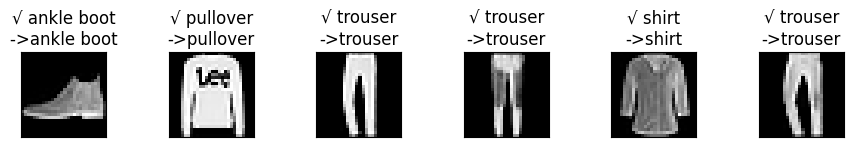

In [ ]:
# 预测与可视化函数
def predict_visualize(
    net: Callable[[Tensor], Tensor],
    test_iter: DataLoader,
    n: int = 6
) -> None:
    """从测试集中取样本进行预测，并将结果可视化。
    
    Args:
        net: 训练好的模型函数。
        test_iter: 测试集数据加载器。
        n: 想要展示的图像数量。
    """
    # 1. 从测试迭代器中抓取一个批次的数据
    # iter() 转化为迭代器，next() 拿到第一个 batch
    X, y = next(iter(test_iter))

    # 2. 准备真实标签的文字
    trues: list[str] = get_fashion_mnist_labels(y)

    # 3. 得到模型的预测结果
    # 经过 net(X) 得到概率，再用 argmax(axis=1) 得到最高概率的索引
    with torch.no_grad():
        preds: list[str] = get_fashion_mnist_labels(net(X).argmax(axis=1))

    # 4. 组合标题：格式为 "True: 实际 \n Pred:预测"
    # 如果预测错误，我们在标题前加 "X" 标记
    titles: list[str] = [
        f"{'√' if t == p else 'X'} {t}\n->{p}"
        for t, p in zip(trues, preds)
    ]

    # 5. 调用之前写好的 show_images 函数
    # X[:n] 取前 n 张图
    show_images(X[:n], 1, n, titles=titles[:n])

# 调用
predict_visualize(net, test_iter, n=6)

## 3.7 Softmax 回归的简洁实现。

In [ ]:
import torch
from torch import nn

def get_soft_max_net(num_inputs: int, num_outputs: int) -> nn.Sequential:
    """构建 Softmax 回归模型。
    
    Args:
        num_inputs: 输入特征维度 (28*28=784)。
        num_outputs: 输出类别数量 (10)。

    Returns:
        包含展平层和线性层的顺序模型。
    """
    # nn.Flatten() 的作用：将 (Batch, 1, 28, 28) 展平为 (Batch, 784)
    net = nn.Sequential(nn.Flatten(), nn.Linear(num_inputs, num_outputs))

    # 初始化权重
    # 写成嵌套函数的原因：命名空间保护 与 逻辑紧凑需求。
    def init_weights(m: nn.Module) -> None:
        if type(m) == nn.Linear:
            # 使用均值为 0，标准差为 0.01 的正态分布初始化权重
            nn.init.normal_(m.weight, std=0.01)
            # 偏置初始化为 0
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    # apply 函数会递归地对 net 里的每一层执行 init_weights
    net.apply(init_weights)
    return net

num_inputs, num_outputs = 784, 10
net = get_soft_max_net(num_inputs, num_outputs)

## 附录：核心类型说明

在处理图像时，我们会接触到以下新类型：
- **`torchvision.datasets`**: PyTorch 官方提供的视觉数据集容器。
- **`torchvision.transforms`**: 图像预处理工具箱（例如将图片转为 Tensor，或者进行归一化）。
- **`torch.uint8`**: 原始图片的像素通常以 0-255 的 8 位无符号整数存储。
- **`torch.float32`**: 神经网络训练时，必须将像素转换为浮点数（通常归一化到 0-1 之间）。
